In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [8]:
# Path to the dataset (notebook is in src/, data is in ../data/)
data_path = os.path.join('..', 'data', 'dataset.csv')

# Load the dataset
print("Loading dataset... this might take a moment.")
df = pd.read_csv(data_path)

# Separate features (25 board positions + 1 turn) and label
X = df.iloc[:, 0:26].values
y = df['label'].values

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Loading dataset... this might take a moment.
Total samples: 199460
Training samples: 159568
Testing samples: 39892


In [9]:
model = models.Sequential([
    layers.Input(shape=(26,)), 
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Standard controlled learning rate
    loss='binary_crossentropy' # MSE could also work, but BCE is fine for probabilities
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=5,               # Wait longer before stopping
    restore_best_weights=True 
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=256, # Smaller batch size for more frequent updates
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 1.3099 - val_loss: 3.2321
Epoch 2/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5.4916 - val_loss: 2.4022
Epoch 3/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 11.6576 - val_loss: 17.2137
Epoch 4/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 18.1935 - val_loss: 19.4795
Epoch 5/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 30.2286 - val_loss: 14.9960
Epoch 6/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 42.4705 - val_loss: 45.3886
Epoch 7/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 58.4633 - val_loss: 50.9502



Evaluating on Test Set...
FINAL TEST LOSS (Binary Cross-Entropy): 2.3823


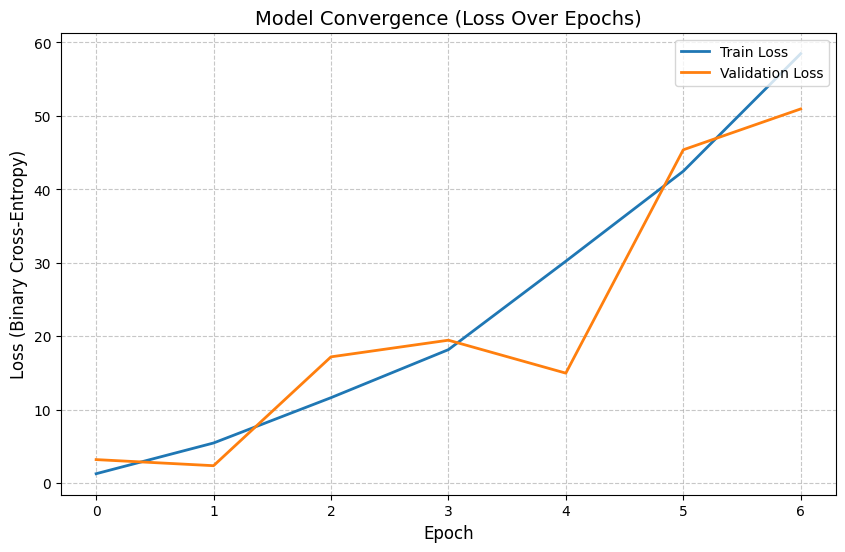


--- Sanity Check: Predictions vs Reality ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Sample 1:
  True Label: 0.5647
  Model Pred: 0.9984
  Difference: 0.4337

Sample 2:
  True Label: 0.7322
  Model Pred: 0.0001
  Difference: 0.7321

Sample 3:
  True Label: 0.5949
  Model Pred: 0.1445
  Difference: 0.4504

Sample 4:
  True Label: 0.9400
  Model Pred: 0.4044
  Difference: 0.5356

Sample 5:
  True Label: 0.7043
  Model Pred: 0.0000
  Difference: 0.7043



In [11]:
# 1. Evaluate on the completely unseen Test Set
print("\nEvaluating on Test Set...")
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"FINAL TEST LOSS (Binary Cross-Entropy): {test_loss:.4f}")

# 2. Plotting the Learning Curve (Loss Only)
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Model Convergence (Loss Over Epochs)', fontsize=14)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# 3. Sanity Check: Let's see some actual predictions vs reality
print("\n--- Sanity Check: Predictions vs Reality ---")
# Predict the first 5 states from the test set
sample_predictions = model.predict(X_test[:5])

for i in range(5):
    true_label = y_test[i]
    prediction = sample_predictions[i][0]
    error_margin = abs(true_label - prediction)
    
    print(f"Sample {i+1}:")
    print(f"  True Label: {true_label:.4f}")
    print(f"  Model Pred: {prediction:.4f}")
    print(f"  Difference: {error_margin:.4f}\n")

In [6]:
# Only run this cell when you are satisfied with the model's performance
model_filename = 'model.keras'
model.save(model_filename)
print(f"SUCCESS: Model saved securely as '{model_filename}' in the src folder.")

SUCCESS: Model saved securely as 'model.keras' in the src folder.
